# How to train a GNS using the Pipeline


## Import classes and define paths


In [1]:
from pyLOM import NN
from pyLOM.NN.utils.config_schema import GNSModelConfig, GNSTrainingConfig
from pyLOM.NN.utils.experiment import plot_train_test_loss, plot_true_vs_pred, save_experiment_artifacts
from pyLOM.utils.config_resolvers import load_yaml
from pathlib import Path
from dacite import from_dict, Config as DaciteConfig
from dataclasses import asdict
import numpy as np
import warnings
warnings.filterwarnings('ignore')


0 Warning! Import - NVTX not present!
/home/p.yeste/miniconda/envs/pylom-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/p.yeste/miniconda/envs/pylom-env/lib/python3.10/site-packages/torch_geometric/typing.py:110: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libc.so.6: version `GLIBC_2.32' not found (required by /home/p.yeste/miniconda/envs/pylom-env/lib/python3.10/site-packages/torch_sparse/_version_cuda.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
/home/p.yeste/miniconda/envs/pylom-env/lib/python3.10/site-packages/xgboost/core.py:390: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a 

In [2]:
CONFIG_PATH = Path.cwd() / 'GNS_training_config.yaml'
if not CONFIG_PATH.exists():
    CONFIG_PATH = Path.cwd() / 'notebook_examples/NN/GNS_training_config.yaml'
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f'Could not find config file. Tried: {Path.cwd() / "GNS_training_config.yaml"} and {Path.cwd() / "notebook_examples/NN/GNS_training_config.yaml"}')
cfg = load_yaml(CONFIG_PATH)
def _resolve(path_like: str) -> Path:
    p = Path(path_like)
    return p if p.is_absolute() else (CONFIG_PATH.parent / p).resolve()
TRAIN_PATH = _resolve(cfg['datasets']['train_ds'])
TEST_PATH = _resolve(cfg['datasets']['test_ds'])
GRAPH_PATH = _resolve(cfg['model']['graph_path'])
CASE_DIR = _resolve(cfg['experiment']['results_path'])
for path in (TRAIN_PATH, TEST_PATH, GRAPH_PATH):
    if not path.exists():
        raise FileNotFoundError(f'Missing required input file: {path}')
NN.create_results_folder(CASE_DIR)
NN.create_results_folder(CASE_DIR / 'models')
NN.create_results_folder(CASE_DIR / 'plots')
print('Config:', CONFIG_PATH)
print('Using files:')
print('  train:', TRAIN_PATH)
print('  test :', TEST_PATH)
print('  graph:', GRAPH_PATH)
print('Results:', CASE_DIR)


Folder already exists: /home/p.yeste/pyLowOrder/docs/source/notebook_examples/NN/results/artifacts
Folder already exists: /home/p.yeste/pyLowOrder/docs/source/notebook_examples/NN/results/artifacts/models
Folder already exists: /home/p.yeste/pyLowOrder/docs/source/notebook_examples/NN/results/artifacts/plots
Config: /home/p.yeste/pyLowOrder/docs/source/notebook_examples/NN/GNS_training_config.yaml
Using files:
  train: /home/p.yeste/pyLowOrder/Testsuite/DATA/CYLINDER_TRAIN.h5
  test : /home/p.yeste/pyLowOrder/Testsuite/DATA/CYLINDER_TEST.h5
  graph: /home/p.yeste/pyLowOrder/Testsuite/DATA/CYLINDER_TRAIN.h5
Results: /home/p.yeste/pyLowOrder/docs/source/notebook_examples/NN/results/artifacts


## Create datasets
For this GNS example, we use the cylinder train/test files and predict the field `VELOX`.


In [3]:
dataset_cfg = cfg['dataset_config']
ds_kwargs = {
    'field_names': dataset_cfg['field_names'],
    'variables_names': dataset_cfg.get('variables_names', ['all']),
    'add_variables': bool(dataset_cfg.get('add_variables', True)),
    'add_mesh_coordinates': bool(dataset_cfg.get('add_mesh_coordinates', False)),
    'squeeze_last_dim': False,
    'channels_last': True,
}
if dataset_cfg.get('mesh_shape') is not None:
    ds_kwargs['mesh_shape'] = tuple(dataset_cfg['mesh_shape'])
train_dataset = NN.Dataset.load(TRAIN_PATH, **ds_kwargs)
test_dataset = NN.Dataset.load(TEST_PATH, **ds_kwargs)


In [4]:
x_train, y_train = train_dataset[:]
x_test, y_test = test_dataset[:]
print('Train dataset length:', len(train_dataset))
print('Test dataset length :', len(test_dataset))
print('X_train shape:', x_train.shape, '| y_train shape:', y_train.shape)
print('X_test  shape:', x_test.shape,  '| y_test  shape:', y_test.shape)


Train dataset length: 12
Test dataset length : 4
X_train shape: torch.Size([12, 1]) | y_train shape: torch.Size([12, 89351, 1])
X_test  shape: torch.Size([4, 1]) | y_test  shape: torch.Size([4, 89351, 1])


## Model creation
GNS uses dataclass-based DTOs for model and training configuration.


In [5]:
dcfg = DaciteConfig(strict=True)
model_cfg = from_dict(GNSModelConfig, cfg['model']['config'], config=dcfg)
training_cfg = from_dict(GNSTrainingConfig, cfg['training'], config=dcfg)


In [6]:
model = NN.GNS.from_graph_path(config=model_cfg, graph_path=GRAPH_PATH)
print(model)


<GNSModel: 1 → 16 → 1>
 Layers: encoder(2), message(1), decoder(1)
 MLPs: message(1), update(1)
 Activation: ELU, Dropout: 0.0, Device: cpu
 Graph: Graph(
  x=[89351, 5],
  edge_index=[2, 356108],
  edge_attr=[356108, 6],
  num_nodes=89351,
  device=cpu,
  xyz=[89351, 2],
  normals=[89351, 3],
  edges_spherical=[356108, 3],
  wall_normals=[356108, 3],
  node_features_dict={
    xyz=[89351, 2],
    normals=[89351, 3],
  },
  edge_features_dict={
    edges_spherical=[356108, 3],
    wall_normals=[356108, 3],
  }
)
 Params: 35,153 trainable
)


## Run the pipeline
Here we use `test_dataset` also as validation dataset to obtain `test_loss` during training.


In [7]:
pipeline = NN.Pipeline(
    train_dataset=train_dataset,
    valid_dataset=test_dataset,
    test_dataset=test_dataset,
    model=model,
    training_params={'config': training_cfg},
)
training_logs = pipeline.run()


[diag] eval batch stats: pred_mean=-0.0594, pred_std=0.0710, targ_mean=0.8338, targ_std=0.3348
[diag] eval epoch: input_batches=3, seed_batches=132, num_losses=132, avg_loss=9.3317e-01
[diag] eval batch stats: pred_mean=-0.2676, pred_std=0.0105, targ_mean=0.8760, targ_std=0.1539
[diag] eval epoch: input_batches=1, seed_batches=44, num_losses=44, avg_loss=1.1489e+00
[diag] Epoch 0 (no training) | Train loss: 9.3317e-01 | Eval loss: 1.1489e+00
[diag] train batch stats: pred_mean=-0.0918, pred_std=0.0799, targ_mean=0.8415, targ_std=0.3291
[diag] train epoch: input_batches=3, seed_batches=132, num_losses=132, avg_loss=1.0941e-01
[diag] eval batch stats: pred_mean=1.0591, pred_std=0.0325, targ_mean=0.8760, targ_std=0.1539
[diag] eval epoch: input_batches=1, seed_batches=44, num_losses=44, avg_loss=1.4471e-01
Epoch 1/2 | Train loss: 1.0941e-01 | Eval loss: 1.4471e-01 | Eval mae(scaled): 2.7061e-01
[diag] train batch stats: pred_mean=0.9811, pred_std=0.1389, targ_mean=0.8345, targ_std=0.3243


## Show plots


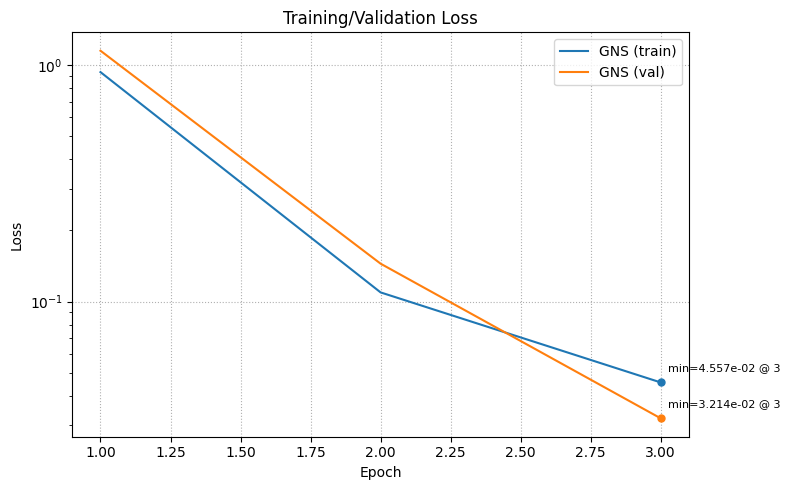

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Training/Validation Loss'}, xlabel='Epoch', ylabel='Loss'>,
 {'GNS (train)': {'min': 0.04556954131377014,
   'argmin': 3.0,
   'last': 0.04556954131377014,
   'n_epochs': 3.0},
  'GNS (val)': {'min': 0.032136169114065444,
   'argmin': 3.0,
   'last': 0.032136169114065444,
   'n_epochs': 3.0}})

In [8]:
loss_dict = {'GNS': {'train': training_logs.get('train_loss', []), 'val': training_logs.get('test_loss', [])}}
plot_train_test_loss(loss_dict, show=True, save=False, yscale='log')


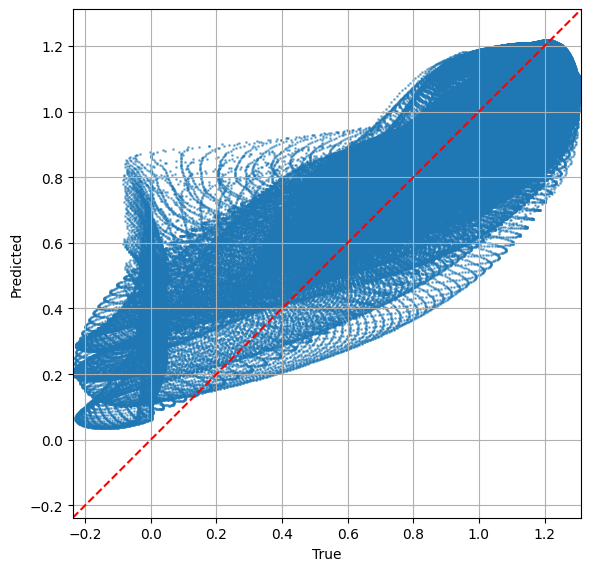

In [9]:
preds = pipeline.model.predict(test_dataset)
if hasattr(preds, 'detach'):
    preds = preds.detach().cpu().numpy()
y_true = y_test.detach().cpu().numpy() if hasattr(y_test, 'detach') else np.asarray(y_test)
preds_flat = preds.reshape(-1, preds.shape[-1])
y_true_flat = y_true.reshape(-1, y_true.shape[-1])
plot_true_vs_pred(y_true_flat, preds_flat)


## Evaluate the model with some metrics


In [10]:
evaluator = NN.RegressionEvaluator()
metrics = evaluator(y_true_flat, preds_flat)
evaluator.print_metrics()



Regression evaluator metrics:
mse: 0.0323
rmse: 0.1798
mae: 0.1367
mre: 21.7953%
ae_95: 0.3615
ae_99: 0.5249
r2: 0.6987
l2_error: 0.2020


## Save experiment artifacts\n

Experiment artifacts saved to: /home/p.yeste/pyLowOrder/docs/source/notebook_examples/NN/results/artifacts/2026-03-16T19-00-25_GNS
Artifacts saved in: /home/p.yeste/pyLowOrder/docs/source/notebook_examples/NN/results/artifacts/2026-03-16T19-00-25_GNS


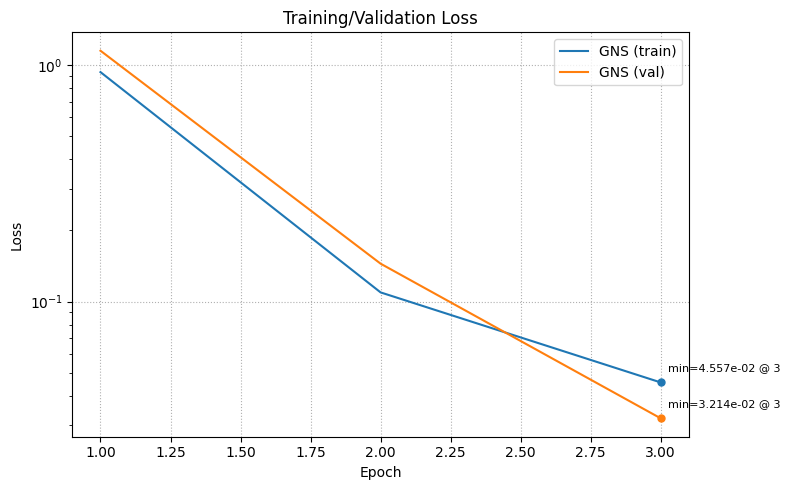

In [11]:
artifacts_dir = save_experiment_artifacts(
    base_path=CASE_DIR,
    model=pipeline.model,
    metrics_dict={k: float(v) for k, v in metrics.items()},
    full_run_config={
        'experiment': cfg.get('experiment', {}),
        'datasets': cfg.get('datasets', {}),
        'dataset_config': cfg.get('dataset_config', {}),
        'model': {'graph_path': str(GRAPH_PATH), 'config': asdict(model_cfg)},
        'training': asdict(training_cfg),
    },
    extra_files={
        'train_val_loss.png': lambda p: plot_train_test_loss(
            {'GNS': {'train': training_logs.get('train_loss', []), 'val': training_logs.get('test_loss', [])}},
            save=True,
            save_path=str(p),
            show=False,
            yscale='log',
        ),
        'true_vs_pred.png': lambda p: plot_true_vs_pred(y_true_flat, preds_flat, p),
    },
    return_path=True,
)
print('Artifacts saved in:', artifacts_dir)


As you can see, this example follows the same Pipeline workflow as the MLP and KAN notebooks. The main differences are the graph-based model construction (`GNS.from_graph_path`) and the GNS-specific DTO configuration (`GNSModelConfig`, `GNSTrainingConfig`).


In [12]:
from pyLOM import Mesh
from pyLOM.NN.utils.experiment import ParaviewExportConfig, export_predictions_to_paraview

mesh = Mesh.load(str(TEST_PATH), mpio=False)
nsnaps = int(preds.shape[0])
field_names = cfg['dataset_config']['field_names']
if not field_names:
    raise ValueError('dataset_config.field_names must contain at least one field')
field_name = str(field_names[0])

# Build per-snapshot input metadata and inverse-scale it when a scaler is available.
x_meta = x_test.detach().cpu().numpy()
x_meta = test_dataset.inverse_scale_inputs(x_meta)
if x_meta.ndim == 1:
    x_meta = x_meta.reshape(-1, 1)

input_names = list(cfg['dataset_config'].get('variables_names', []))
if len(input_names) != x_meta.shape[1]:
    input_names = [f'input_{i}' for i in range(x_meta.shape[1])]
snapshot_metadata = {str(name): x_meta[:, i] for i, name in enumerate(input_names)}

pv_cfg = ParaviewExportConfig(
    mesh=mesh,
    cell_order=mesh.cellOrder,
    partition_table=mesh.partition_table,
    instants=np.arange(nsnaps, dtype=np.int32),
    times=np.arange(nsnaps, dtype=np.float64),
    output_dir=Path(artifacts_dir) / 'paraview',
    base_name='gns_predictions',
    mode='single',
    snapshot_metadata=snapshot_metadata,
    extra_cell_fields={field_name: y_true},
)

written_files = export_predictions_to_paraview(
    y_pred=preds,
    y_true=y_true,
    metrics=[
        (f'{field_name}_pred', lambda yp, yt: yp),
        ('error', lambda yp, yt: np.abs(yp - yt)),
    ],
    config=pv_cfg,
)

print('ParaView files written:')
for wf in written_files:
    print(' -', wf)


ParaView files written:
 - /home/p.yeste/pyLowOrder/docs/source/notebook_examples/NN/results/artifacts/2026-03-16T19-00-25_GNS/paraview/gns_predictions.vtk.hdf
 - /home/p.yeste/pyLowOrder/docs/source/notebook_examples/NN/results/artifacts/2026-03-16T19-00-25_GNS/paraview/gns_predictions__snapshot_labels.json
